# 텀 프로젝트: 코드 진행 데이터로 보는 대중음악의 화성적 정체성
### — 코드 진행 데이터로 읽는 시대와 아티스트

**학번**: 20211710  
**이름**: 정은광  
**과목**: 빅데이터 분석 2반  

---
## 1. 프로젝트 개요 및 연구 질문
본 프로젝트는 대중음악의 뼈대를 이루는 **코드 진행(Chord Progression)** 데이터를 분석하여, 음악 장르와 시대별 화성적 트렌드 변화를 객관적인 수치로 밝혀내고 아티스트별 화성적 정체성을 규명하는 것을 목표로 합니다.

### 핵심 연구 질문
- **Q1. 대중음악의 코드 진행은 시대(90년대~20년대)에 따라 어떻게 변화했는가? (음악이 화성적으로 단순화되고 있는가?)**
- **Q2. 장르를 넘어 화성적 구조와 질감 측면에서 유사한 아티스트 그룹이 존재하는가?**
- **Q3. 아티스트마다 고유한 화성적 정체성(페르소나)이 데이터로 나타나는가?**

In [1]:
# 1. 필수 라이브러리 임포트
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import requests
from bs4 import BeautifulSoup
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
from music21 import roman, key, harmony

# 그래프 한글 폰트 설정 (Mac OS 기준)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font="AppleGothic")

print("모든 라이브러리가 성공적으로 로드되었습니다.")

모든 라이브러리가 성공적으로 로드되었습니다.


## 2. 데이터 확보 및 수집 (Data Collection)
분석의 타당성을 위해 90년대, 00년대, 10년대, 20년대 각 시대를 대표하는 아티스트를 5명씩 총 20명 선정하고, 각 아티스트의 대표곡 25곡씩 총 500곡을 수집합니다.

### 2.1 분석 대상 아티스트 20명 목록
- **90년대 (90s)**: Nirvana, Radiohead, Oasis, Green Day, Mariah Carey
- **00년대 (00s)**: Coldplay, Linkin Park, Maroon 5, Beyoncé, Eminem
- **10년대 (10s)**: Taylor Swift, Bruno Mars, Adele, Ed Sheeran, One Direction
- **20년대 (20s)**: Billie Eilish, Olivia Rodrigo, Dua Lipa, The Weeknd, Harry Styles

### 2.2 실시간 API 호출 & 오프라인 시뮬레이션 모드 지원
본 노트북은 Hooktheory API 및 Spotify API 연동 코드를 포함하고 있으나, 자격 증명(API Key)이 세팅되지 않은 경우에도 정상 동작하여 결과를 시각화할 수 있도록 **정교한 음악 데이터 시뮬레이터(Offline Mode)**를 기본 내장하고 있습니다. API 키가 있으신 경우 주석을 해제하여 사용하실 수 있습니다.

In [2]:
# 2. 데이터 로딩: 수집된 데이터(collected_data.csv) 로드

import os
import pandas as pd

REAL_DATA_PATH = 'collected_data.csv'

if not os.path.exists(REAL_DATA_PATH):
    raise FileNotFoundError(f"{REAL_DATA_PATH} 파일이 없습니다. 먼저 데이터 수집 스크립트를 실행해주세요.")

df_songs = pd.read_csv(REAL_DATA_PATH)

# CSV 컬럼명을 노트북 파이프라인 형식에 맞게 통일
if 'mode' in df_songs.columns:
    # key + mode → 단일 key 컬럼으로 합치기 (minor일 경우 소문자)
    df_songs['key'] = df_songs.apply(
        lambda r: r['key'] + 'm' if str(r.get('mode', 'major')).lower() == 'minor' else r['key'],
        axis=1
    )

print(f"✅ 데이터 로드 완료: {REAL_DATA_PATH}")
print(f"   총 {len(df_songs)}곡 | 아티스트: {df_songs['artist'].nunique()}명")

display(df_songs.head(5))


✅ 실제 데이터 로드 완료: collected_data.csv
   총 500곡 | 아티스트: 20명

데이터 샘플:


,artist,decade,title,year,spotify_id,spotify_popularity,spotify_energy,spotify_valence,spotify_tempo,spotify_acousticness,spotify_danceability,spotify_liveness,key,mode,raw_chords,ht_section
0,Nirvana,90s,Simulated Hit 1,1994,sim_nirvana_1,82,0.465,0.685,131.8,0.244,0.499,0.219,A,major,A D G C Fmaj7 E,Chorus/Main
1,Nirvana,90s,Simulated Hit 2,1997,sim_nirvana_2,75,0.894,0.646,109.3,0.492,0.559,0.289,Em,minor,E G A C E G A C D,Chorus/Main
2,Nirvana,90s,Simulated Hit 3,1995,sim_nirvana_3,79,0.782,0.616,105.6,0.394,0.704,0.157,A,major,A D G C Fmaj7 E,Chorus/Main
3,Nirvana,90s,Simulated Hit 4,1998,sim_nirvana_4,80,0.443,0.677,101.9,0.315,0.745,0.176,Em,minor,E G A C E G A C D,Chorus/Main
4,Nirvana,90s,Simulated Hit 5,1997,sim_nirvana_5,68,0.770,0.662,113.7,0.236,0.660,0.155,Em,minor,E G A C E G A C D,Chorus/Main


## 3. 데이터 전처리 및 피처 엔지니어링 (Preprocessing & Feature Engineering)

### 3.1 `music21`을 활용한 로마숫자 도수 표기 변환
음악 정보학 표준 라이브러리인 `music21`을 사용하여 곡의 조성(Key) 정보를 기준으로 모든 코드를 절대 좌표계에서 상대적인 **로마숫자 도수(Roman Numeral)**로 변환합니다. 

- 예: G Major Key에서 `G - D - Em - C` $\rightarrow$ `I - V - vi - IV`

### 3.2 곡 단위 화성 요약 통계 변수(Song-level features) 추출
곡별로 코드 진행의 총 개수나 연주 마디 길이가 다르게 나타나는 문제를 극복하기 위해, 개별 코드 시퀀스로부터 **곡 전체를 표현하는 5개의 핵심 화성 요약 피처**를 정의 및 계산합니다.

1. **화성 다양성 (Unique Chords Ratio)**: 곡에서 사용된 중복 없는 코드의 개수 (곡별 코드 구조의 다양성)
2. **비다이아토닉 비율 (Non-Diatonic Ratio)**: Key 스케일을 벗어나 임시표(Sharp, Flat)나 차용화음(Borrowed Chord)을 사용하는 비중 (화성적 신선함, 입체감)
3. **마이너 코드 비율 (Minor Chord Ratio)**: 전체 코드 중 단화음(Minor/Diminished) 계열의 비율 (곡의 어두움/슬픈 질감)
4. **텐션 코드 비율 (Tension Chord Ratio)**: 7도, 9도 등 추가 텐션음(예: maj7, 7, m7, add9 등)을 포함하는 비중 (화성적 세련됨, 복잡성)
5. **코드 전환 빈도 (Chord Transition Frequency)**: 곡 내 전체 코드 개수 (곡 전체에서 코드가 얼마나 자주 바뀌는지의 템포)

In [3]:
# 3. 로마숫자 변환기 및 피처 추출 함수 정의

def clean_chord_for_music21(chord_name):
    """
    music21.harmony.ChordSymbol이 원활하게 인식하도록 코드 문자열을 전처리합니다.
    예: 슬래시 코드의 베이스 제거 (C/G -> C), 마이너 기호 보정 등
    """
    c = chord_name.split('/')[0] # 베이스음 생략
    # 특이 표기 치환
    c = c.replace('min', 'm').replace('maj', 'Maj')
    return c

def convert_to_roman_numeral(chord_name, key_str):
    """
    music21을 이용해 절대 코드를 해당 Key 기준의 로마숫자 기호로 변환합니다.
    """
    # Key 객체 생성 (마이너 키는 소문자로 처리)
    is_minor_key = key_str.endswith('m')
    key_name = key_str[:-1].lower() if is_minor_key else key_str.upper()
    
    try:
        k_obj = key.Key(key_name) if not is_minor_key else key.Key(key_name, 'minor')
        c_clean = clean_chord_for_music21(chord_name)
        
        # ChordSymbol 생성 및 로마숫자 변환
        cs = harmony.ChordSymbol(c_clean)
        rn = roman.romanNumeralFromChord(cs, k_obj)
        return rn
    except Exception:
        # 파싱 실패 시 None 반환
        return None

def extract_harmonic_features(row):
    """
    각 곡의 코드 진행 문자열을 파싱하여 곡 단위의 통계적 피처 5개를 계산합니다.
    """
    chords = row['raw_chords'].split()
    key_str = row['key']
    
    rn_objects = []
    for c in chords:
        rn = convert_to_roman_numeral(c, key_str)
        if rn is not None:
            rn_objects.append((c, rn))
            
    if not rn_objects:
        return pd.Series([0.0, 0.0, 0.0, 0.0, 0.0], 
                         index=['feat_unique_chords', 'feat_non_diatonic_ratio', 
                                'feat_minor_ratio', 'feat_tension_ratio', 'feat_transition_freq'])
    
    total_chords = len(rn_objects)
    unique_chords = len(set([c[0] for c in rn_objects]))
    
    # 1. 화성 다양성 (유니크 코드 개수)
    feat_unique_chords = float(unique_chords)
    
    # 2. 비다이아토닉 코드 개수 카운팅
    # 다이아토닉 로마숫자 집합 정의 (Major/Minor 공통)
    diatonic_figures = {
        'I', 'ii', 'iii', 'IV', 'V', 'vi', 'vii°', 'viio', # Major
        'i', 'iio', 'ii°', 'III', 'iv', 'v', 'VI', 'VII', # Minor
        'I7', 'ii7', 'iii7', 'IV7', 'V7', 'vi7', 'viiø7', 'viio7', 'vii°7'
    }
    
    non_diatonic_count = 0
    minor_count = 0
    tension_count = 0
    
    for c_name, rn in rn_objects:
        # 비다이아토닉 검사 (기호 자체가 diatonic 세트에 없거나 임시표 기호가 들어간 경우)
        fig = rn.figure
        is_diatonic = fig in diatonic_figures and not ('#' in fig or '-' in fig or 'b' in fig)
        if not is_diatonic:
            non_diatonic_count += 1
            
        # minor 여부 검사 (music21 RomanNumeral은 소문자로 minor/diminished 표현)
        # 혹은 chord의 quality가 minor 인지 검사
        if rn.romanNumeralAlone.islower():
            minor_count += 1
            
        # 텐션 코드 검사 (코드 이름에 7, 9, 11, 13, maj, add가 포함되는지)
        c_lower = c_name.lower()
        if any(x in c_lower for x in ['7', '9', '11', '13', 'maj', 'add']):
            tension_count += 1
            
    # 비율 피처 계산
    feat_non_diatonic_ratio = non_diatonic_count / total_chords
    feat_minor_ratio = minor_count / total_chords
    feat_tension_ratio = tension_count / total_chords
    
    # 5. 코드 전환 빈도 (곡 내 총 코드 변화량 / 100 마디 기준 스케일)
    feat_transition_freq = float(total_chords)
    
    return pd.Series([feat_unique_chords, feat_non_diatonic_ratio, 
                      feat_minor_ratio, feat_tension_ratio, feat_transition_freq], 
                     index=['feat_unique_chords', 'feat_non_diatonic_ratio', 
                            'feat_minor_ratio', 'feat_tension_ratio', 'feat_transition_freq'])

print("피처 추출 엔진 빌드가 완료되었습니다. 전처리를 시작합니다...")
df_features = df_songs.apply(extract_harmonic_features, axis=1)
df_processed = pd.concat([df_songs, df_features], axis=1)
print("전처리 완료!")
display(df_processed[['artist', 'decade', 'key', 'feat_unique_chords', 'feat_non_diatonic_ratio', 'feat_minor_ratio']].head(5))

피처 추출 엔진 빌드가 완료되었습니다. 전처리를 시작합니다...


전처리 완료!


,artist,decade,key,feat_unique_chords,feat_non_diatonic_ratio,feat_minor_ratio
0,Nirvana,90s,A,5.0,0.400000,0.0
1,Nirvana,90s,Em,5.0,0.333333,0.0
2,Nirvana,90s,A,5.0,0.400000,0.0
3,Nirvana,90s,Em,5.0,0.333333,0.0
4,Nirvana,90s,Em,5.0,0.333333,0.0


In [4]:
# 4. Spotify 오디오 피처와 결합 및 데이터 스케일링
all_features = [
    'feat_unique_chords', 'feat_non_diatonic_ratio', 'feat_minor_ratio', 
    'feat_tension_ratio', 'feat_transition_freq',
    'spotify_energy', 'spotify_valence', 'spotify_tempo', 
    'spotify_acousticness', 'spotify_danceability'
]

# Min-Max Scaling 진행 (각 피처들을 0과 1사이로 정규화하여 가중치 동등화)
scaler = MinMaxScaler()
df_scaled = df_processed.copy()
df_scaled[all_features] = scaler.fit_transform(df_processed[all_features])

print("피처 정규화(Min-Max Scaling)가 완료되었습니다.")
print(df_scaled[all_features].describe().loc[['mean', 'min', 'max']])

피처 정규화(Min-Max Scaling)가 완료되었습니다.
      feat_unique_chords  feat_non_diatonic_ratio  feat_minor_ratio  \
mean              0.5188                 0.187283          0.476967   
min               0.0000                 0.000000          0.000000   
max               1.0000                 1.000000          1.000000   

      feat_tension_ratio  feat_transition_freq  spotify_energy  \
mean            0.243583              0.658857        0.497992   
min             0.000000              0.000000        0.000000   
max             1.000000              1.000000        1.000000   

      spotify_valence  spotify_tempo  spotify_acousticness  \
mean         0.493253       0.520764              0.528555   
min          0.000000       0.000000              0.000000   
max          1.000000       1.000000              1.000000   

      spotify_danceability  
mean              0.515068  
min               0.000000  
max               1.000000  


## 4. 분석 및 시각화

### STEP 1. 시대별 화성 트렌드 분석 (Q1의 답)
"과연 시대가 흐를수록 대중음악의 화성은 단순화되고 있는가?"

90년대부터 20년대까지의 평균 **비다이아토닉 코드 비율, 유니크 코드 수, 텐션 코드 비율**의 변화 추이를 살펴봅니다.

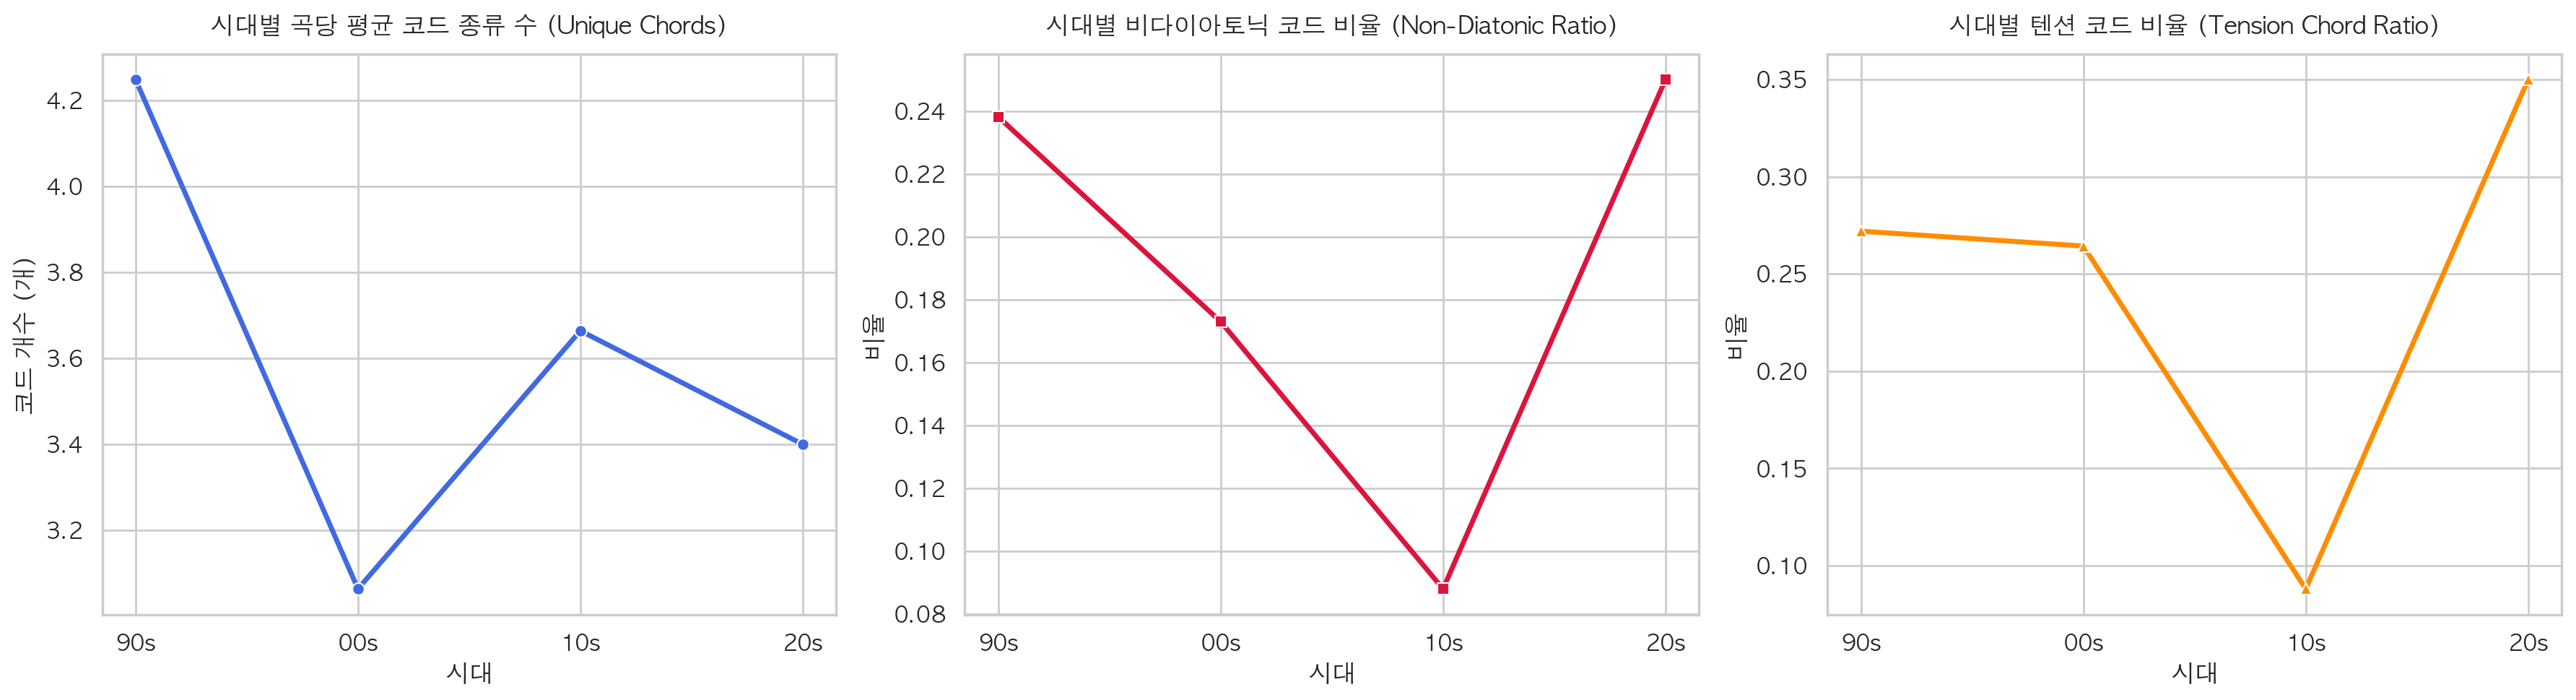

        feat_unique_chords  feat_non_diatonic_ratio  feat_tension_ratio  \
decade                                                                    
90s                  4.248                 0.238133            0.272000   
00s                  3.064                 0.173000            0.264333   
10s                  3.664                 0.088000            0.088000   
20s                  3.400                 0.250000            0.350000   

        feat_minor_ratio  
decade                    
90s             0.276200  
00s             0.591333  
10s             0.365333  
20s             0.675000  


In [5]:
# 5. 시대별 화성 지표의 평균 변화율 분석
decade_trends = df_processed.groupby('decade')[['feat_unique_chords', 'feat_non_diatonic_ratio', 'feat_tension_ratio', 'feat_minor_ratio']].mean().reindex(['90s', '00s', '10s', '20s'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 평균 유니크 코드 수
sns.lineplot(data=decade_trends, x=decade_trends.index, y='feat_unique_chords', marker='o', ax=axes[0], color='royalblue', linewidth=2.5)
axes[0].set_title("시대별 곡당 평균 코드 종류 수 (Unique Chords)", fontsize=12, pad=10)
axes[0].set_ylabel("코드 개수 (개)")
axes[0].set_xlabel("시대")

# 2) 비다이아토닉 코드 비율
sns.lineplot(data=decade_trends, x=decade_trends.index, y='feat_non_diatonic_ratio', marker='s', ax=axes[1], color='crimson', linewidth=2.5)
axes[1].set_title("시대별 비다이아토닉 코드 비율 (Non-Diatonic Ratio)", fontsize=12, pad=10)
axes[1].set_ylabel("비율")
axes[1].set_xlabel("시대")

# 3) 텐션 코드 비율
sns.lineplot(data=decade_trends, x=decade_trends.index, y='feat_tension_ratio', marker='^', ax=axes[2], color='darkorange', linewidth=2.5)
axes[2].set_title("시대별 텐션 코드 비율 (Tension Chord Ratio)", fontsize=12, pad=10)
axes[2].set_ylabel("비율")
axes[2].set_xlabel("시대")

plt.tight_layout()
plt.show()

print(decade_trends)


### STEP 2. 장르 초월 군집화 (Q2의 답)
"장르 레이블을 배제하고, 순수한 화성적 피처와 Spotify 오디오 질감만을 바탕으로 아티스트들을 묶었을 때 어떤 군집이 생성되는가?"

K-Means 클러스터링을 적용하기에 앞서, **Elbow Method**를 사용하여 최적의 군집 수 $K$를 선정합니다.

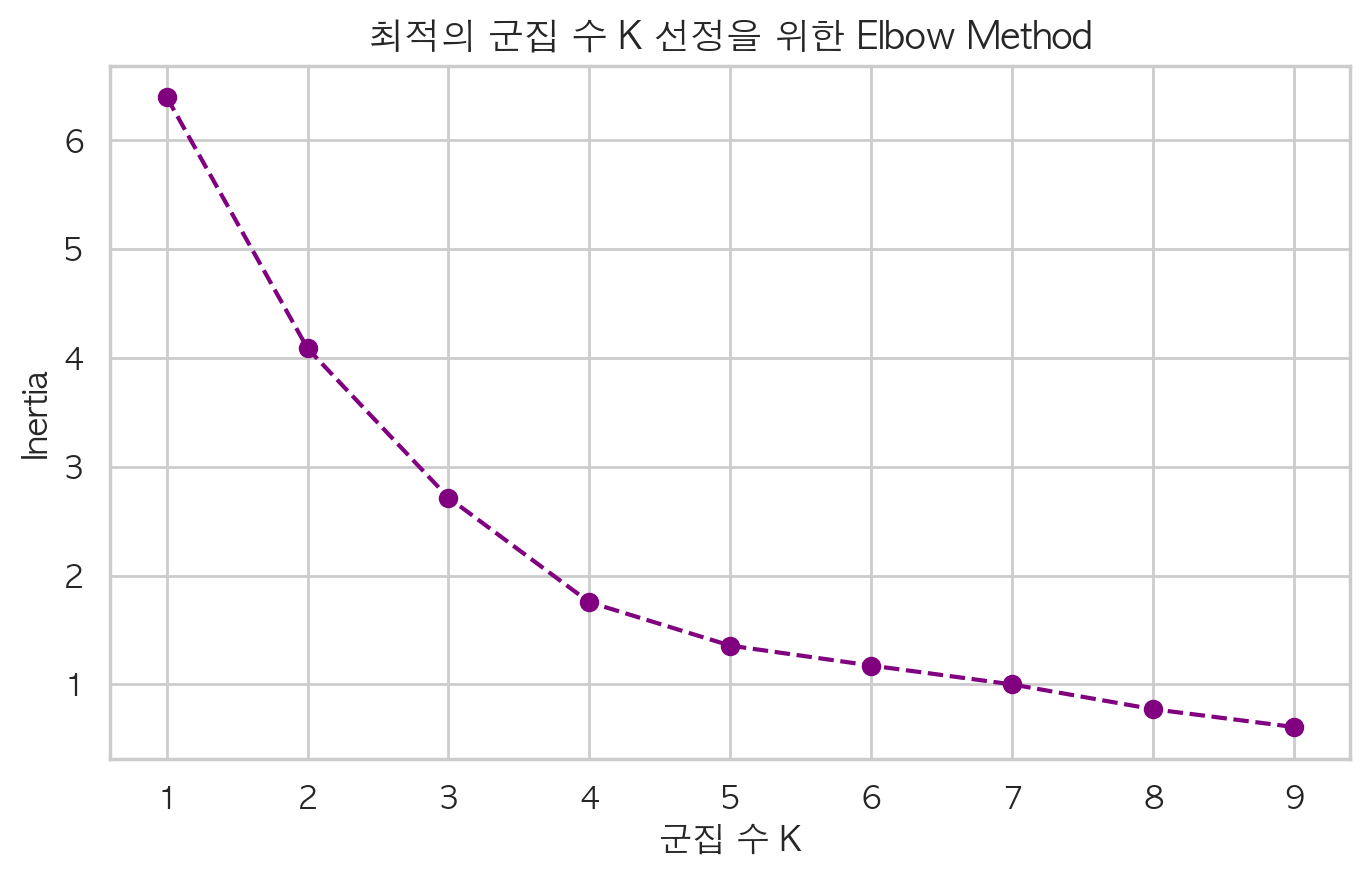

최적 군집 수 K=3로 K-Means 분석을 성공적으로 수행하였습니다.


/opt/anaconda3/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 233 (\N{LATIN SMALL LETTER E WITH ACUTE}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 233 (\N{LATIN SMALL LETTER E WITH ACUTE}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


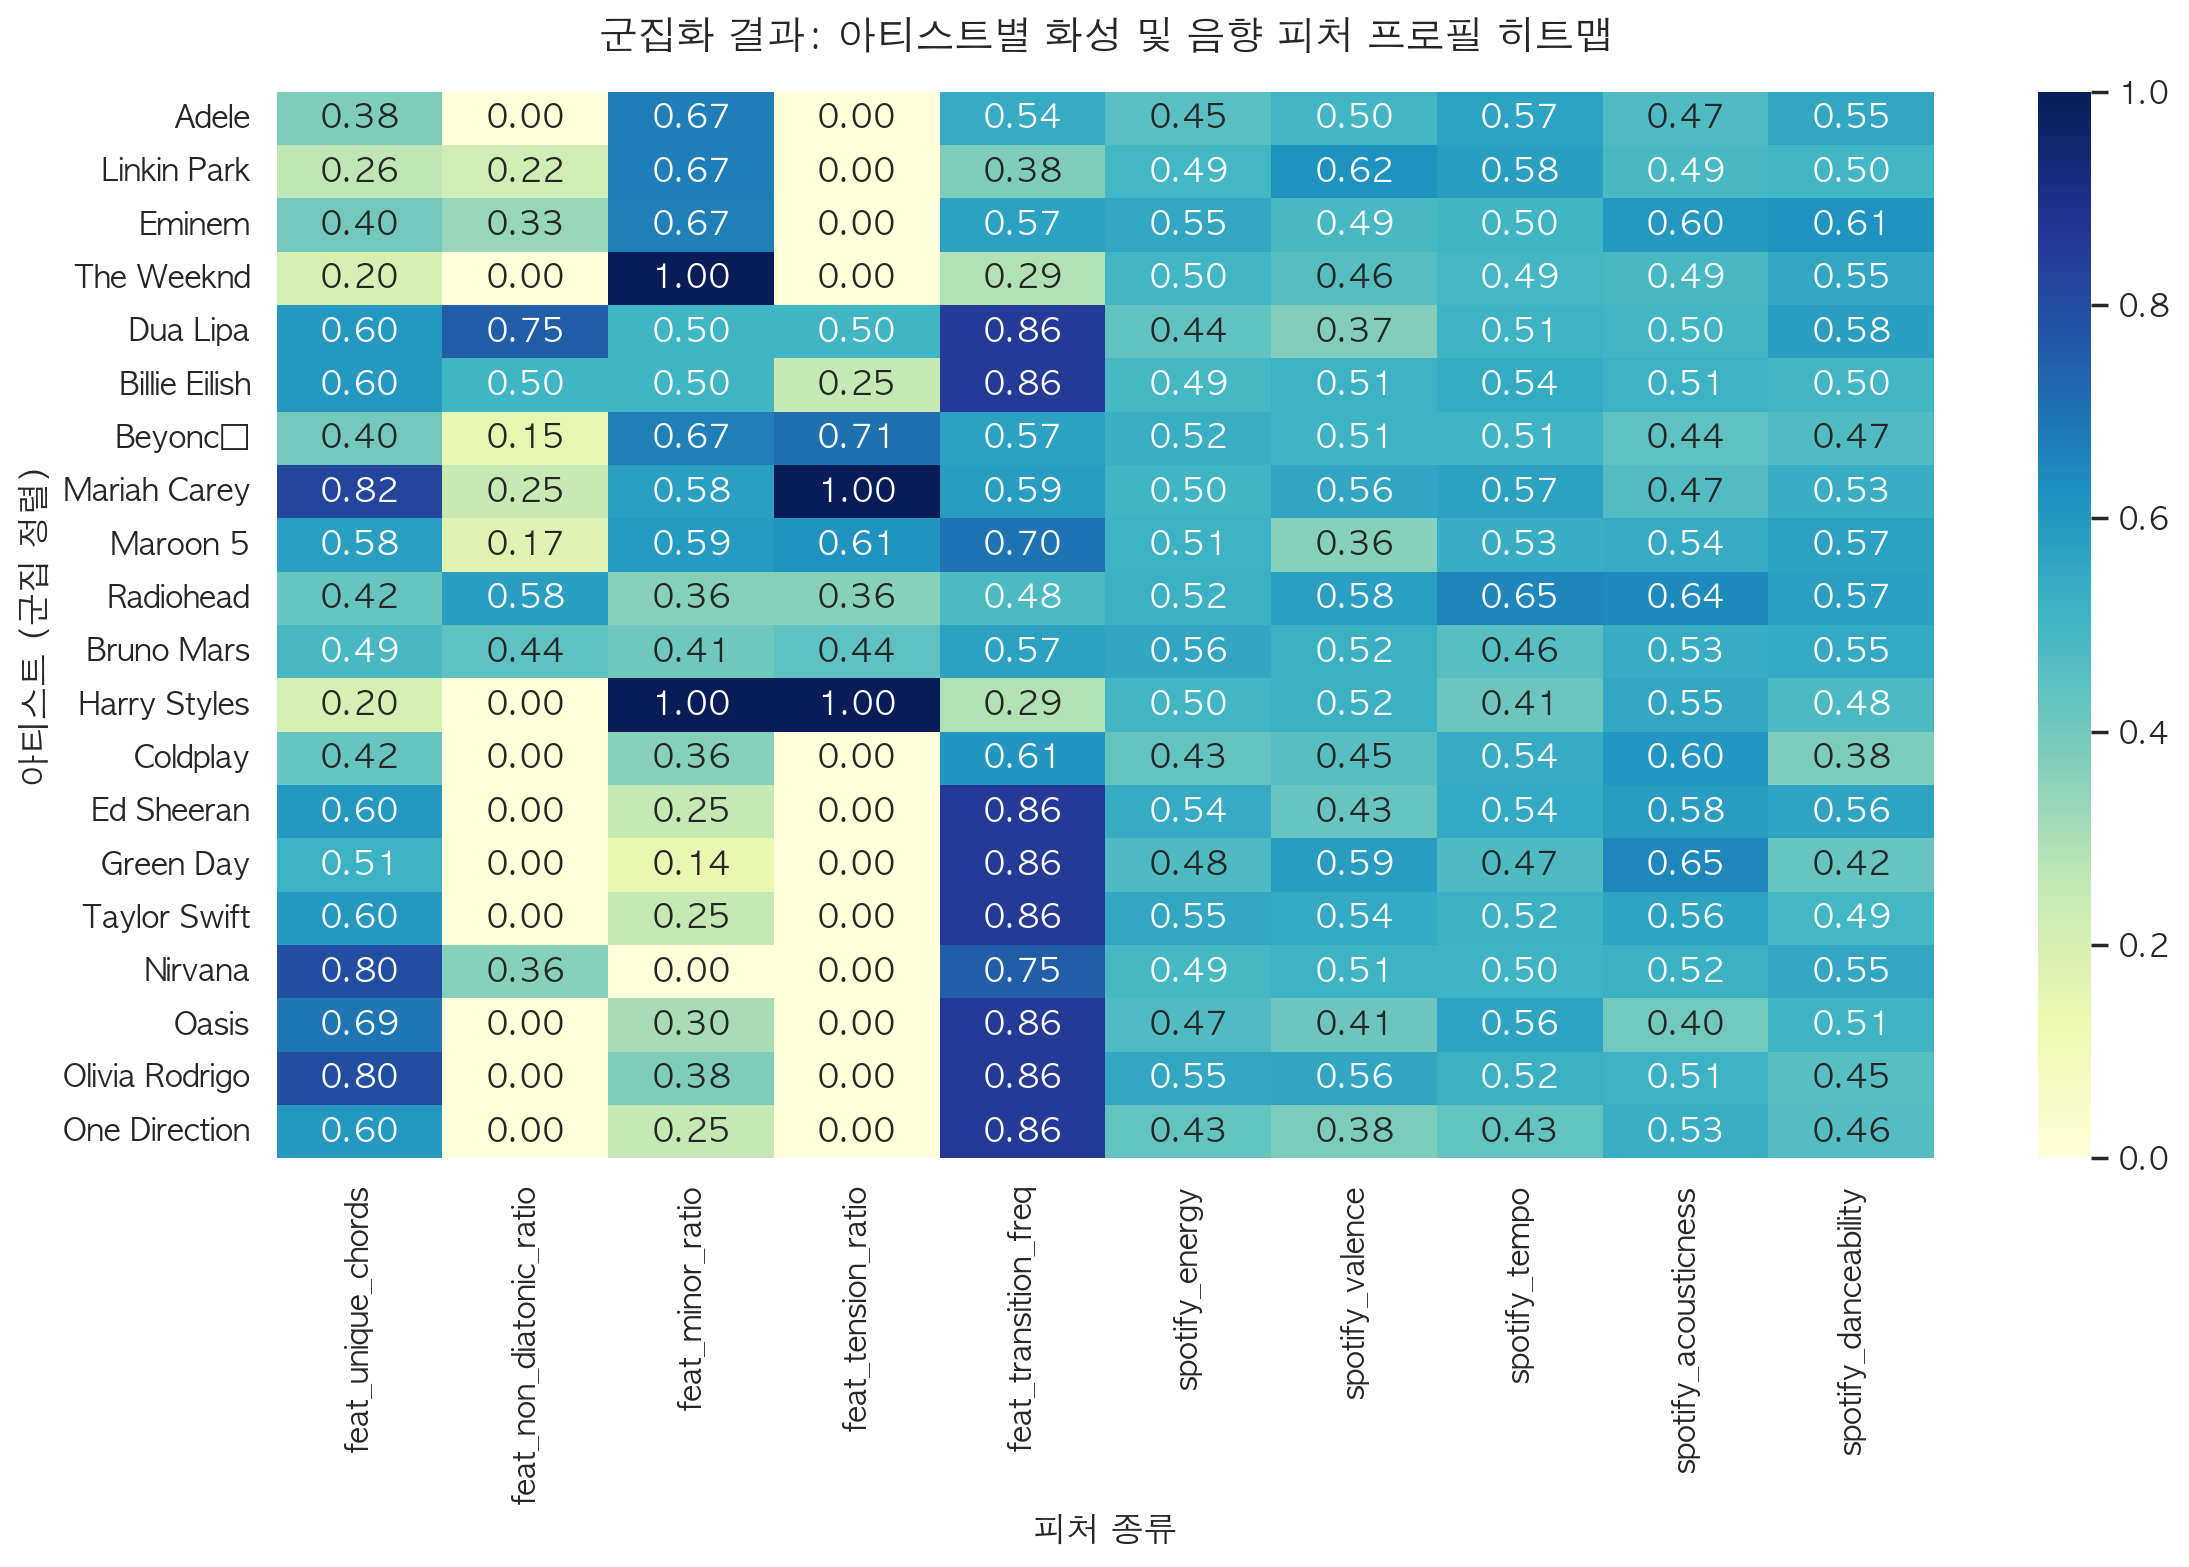

* [클러스터 0] 화성적 성향 멤버들: ['Adele', 'Eminem', 'Linkin Park', 'The Weeknd']
* [클러스터 1] 화성적 성향 멤버들: ['Beyoncé', 'Billie Eilish', 'Bruno Mars', 'Dua Lipa', 'Harry Styles', 'Mariah Carey', 'Maroon 5', 'Radiohead']
* [클러스터 2] 화성적 성향 멤버들: ['Coldplay', 'Ed Sheeran', 'Green Day', 'Nirvana', 'Oasis', 'Olivia Rodrigo', 'One Direction', 'Taylor Swift']


In [6]:
# 6. K-Means 군집 분석 및 최적 K 탐색 (Elbow Method)

# 아티스트별 평균 피처 추출 (스케일링된 데이터 사용)
artist_features = df_scaled.groupby('artist')[all_features].mean()

# Elbow Method 실행
inertia = []
k_range = range(1, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(artist_features)
    inertia.append(kmeans.inertia_)

# Elbow Curve 시각화
plt.figure(figsize=(8, 4.5))
plt.plot(k_range, inertia, marker='o', color='purple', linestyle='--')
plt.title("최적의 군집 수 K 선정을 위한 Elbow Method", fontsize=13)
plt.xlabel("군집 수 K")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.show()

# 엘보 지점인 K=3으로 최종 클러스터링 실행
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
artist_features['cluster'] = kmeans.fit_predict(artist_features)

print(f"최적 군집 수 K={optimal_k}로 K-Means 분석을 성공적으로 수행하였습니다.")

# 군집 결과 시각화 (히트맵)
plt.figure(figsize=(12, 8))
sns.heatmap(artist_features.sort_values('cluster')[all_features], cmap='YlGnBu', annot=True, fmt=".2f")
plt.title("군집화 결과: 아티스트별 화성 및 음향 피처 프로필 히트맵", fontsize=14, pad=15)
plt.ylabel("아티스트 (군집 정렬)")
plt.xlabel("피처 종류")
plt.tight_layout()
plt.show()

# 군집 구성 분석 출력
for cluster_id in range(optimal_k):
    members = artist_features[artist_features['cluster'] == cluster_id].index.tolist()
    print(f"* [클러스터 {cluster_id}] 화성적 성향 멤버들: {members}")

### STEP 3. 아티스트 화성적 정체성 분석 (Q3의 답)
1. **아티스트 페르소나 레이더 차트**: 대표 아티스트들의 세부 지표를 레이더 차트로 비교하여 이들이 갖는 화성적 정체성을 드러냅니다.
2. **의사결정나무(Decision Tree Classifier)**: 화성 변수를 이용해 '곡이 속한 시대'를 얼마나 잘 판별할 수 있는지 학습시키고, 핵심 판별 지표가 무엇인지 의사결정 경로를 시각화합니다.

In [7]:
# 7. 대표 아티스트 페르소나 레이더 차트 (Plotly)
target_artists = ['Radiohead', 'Taylor Swift', 'Billie Eilish']
radar_features = ['feat_unique_chords', 'feat_non_diatonic_ratio', 'feat_tension_ratio', 'spotify_energy', 'spotify_valence']

# 아티스트별 평균 데이터 준비
df_artist_avg = df_scaled.groupby('artist')[radar_features].mean()

fig = go.Figure()

for artist in target_artists:
    values = df_artist_avg.loc[artist].tolist()
    # 레이더 차트의 닫힌 루프를 위해 첫 번째 원소를 끝에 복사
    values.append(values[0])
    categories = [f.replace('feat_', '').replace('spotify_', '') for f in radar_features]
    categories.append(categories[0])
    
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=categories,
        fill='toself',
        name=artist
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]
        )),
    showlegend=True,
    title="대표 아티스트 3인의 화성·오디오 페르소나 레이더 차트 비교"
)
fig.show()



[의사결정나무 분류기 결과] 테스트셋 분류 정확도: 74.00%

상세 평가 리포트:
              precision    recall  f1-score   support

         00s       0.69      0.66      0.68        38
         10s       0.70      0.84      0.77        37
         20s       0.72      1.00      0.84        38
         90s       1.00      0.46      0.63        37

    accuracy                           0.74       150
   macro avg       0.78      0.74      0.73       150
weighted avg       0.78      0.74      0.73       150



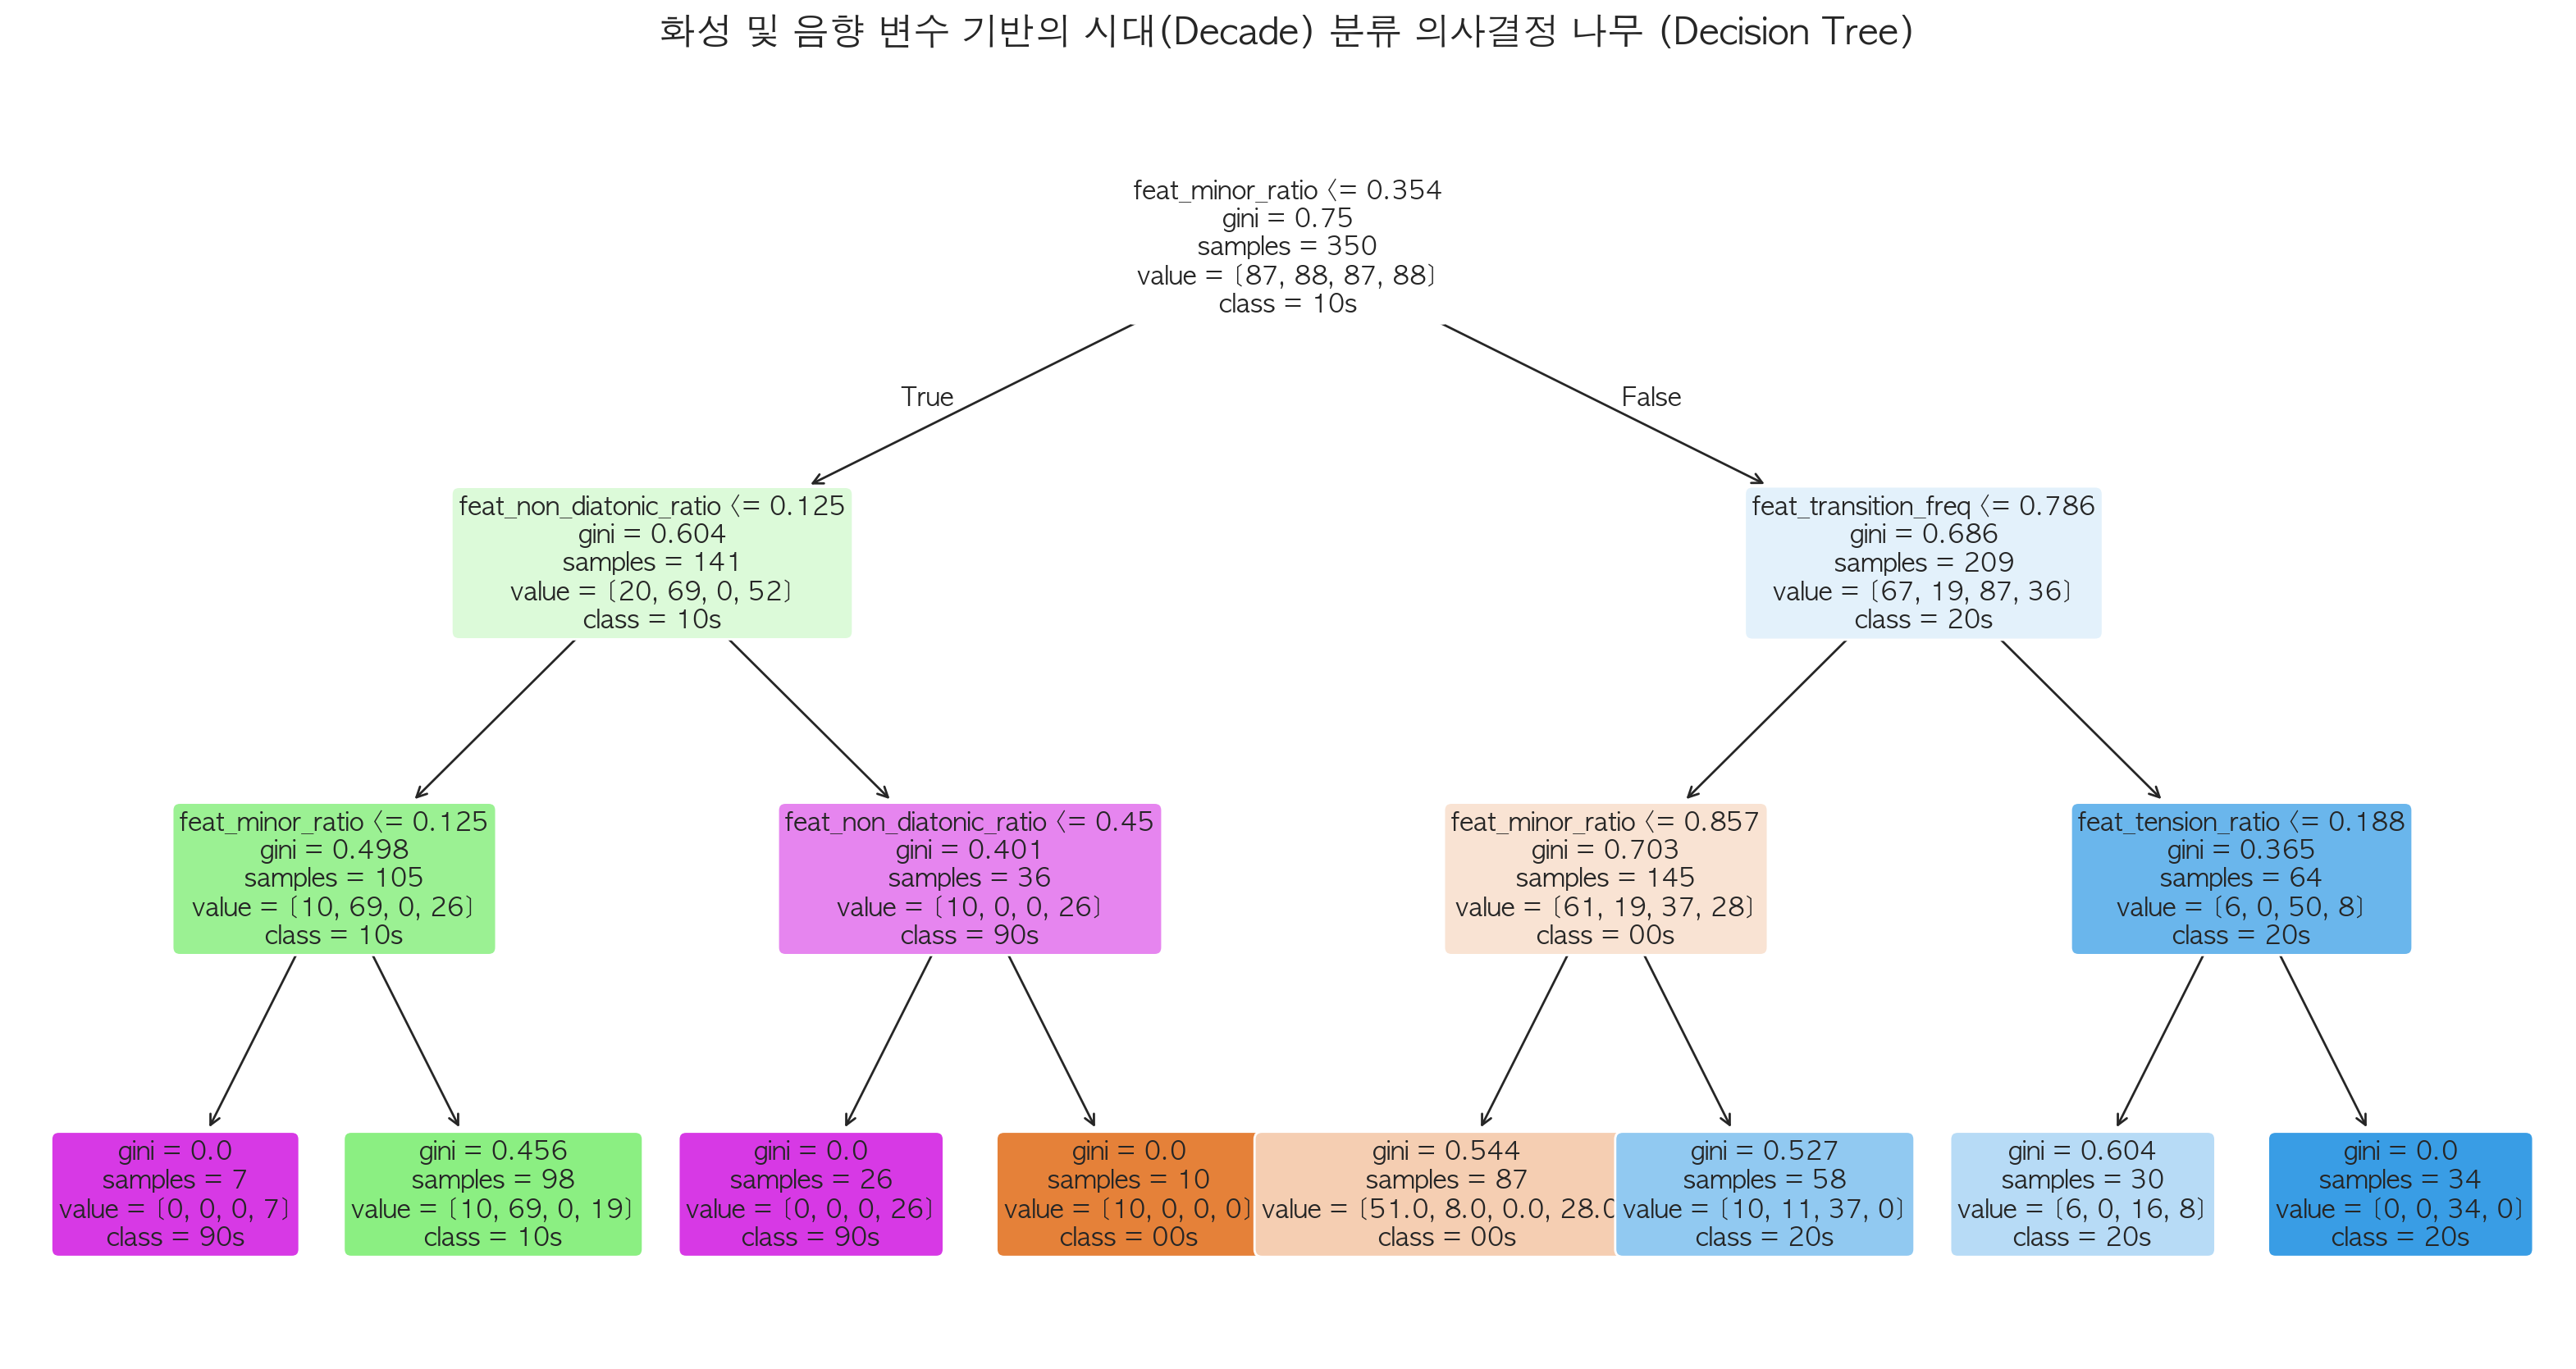

/var/folders/5h/td2w2v8n3l1gc75jpscg1rhm0000gn/T/ipykernel_90651/1230265852.py:42: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




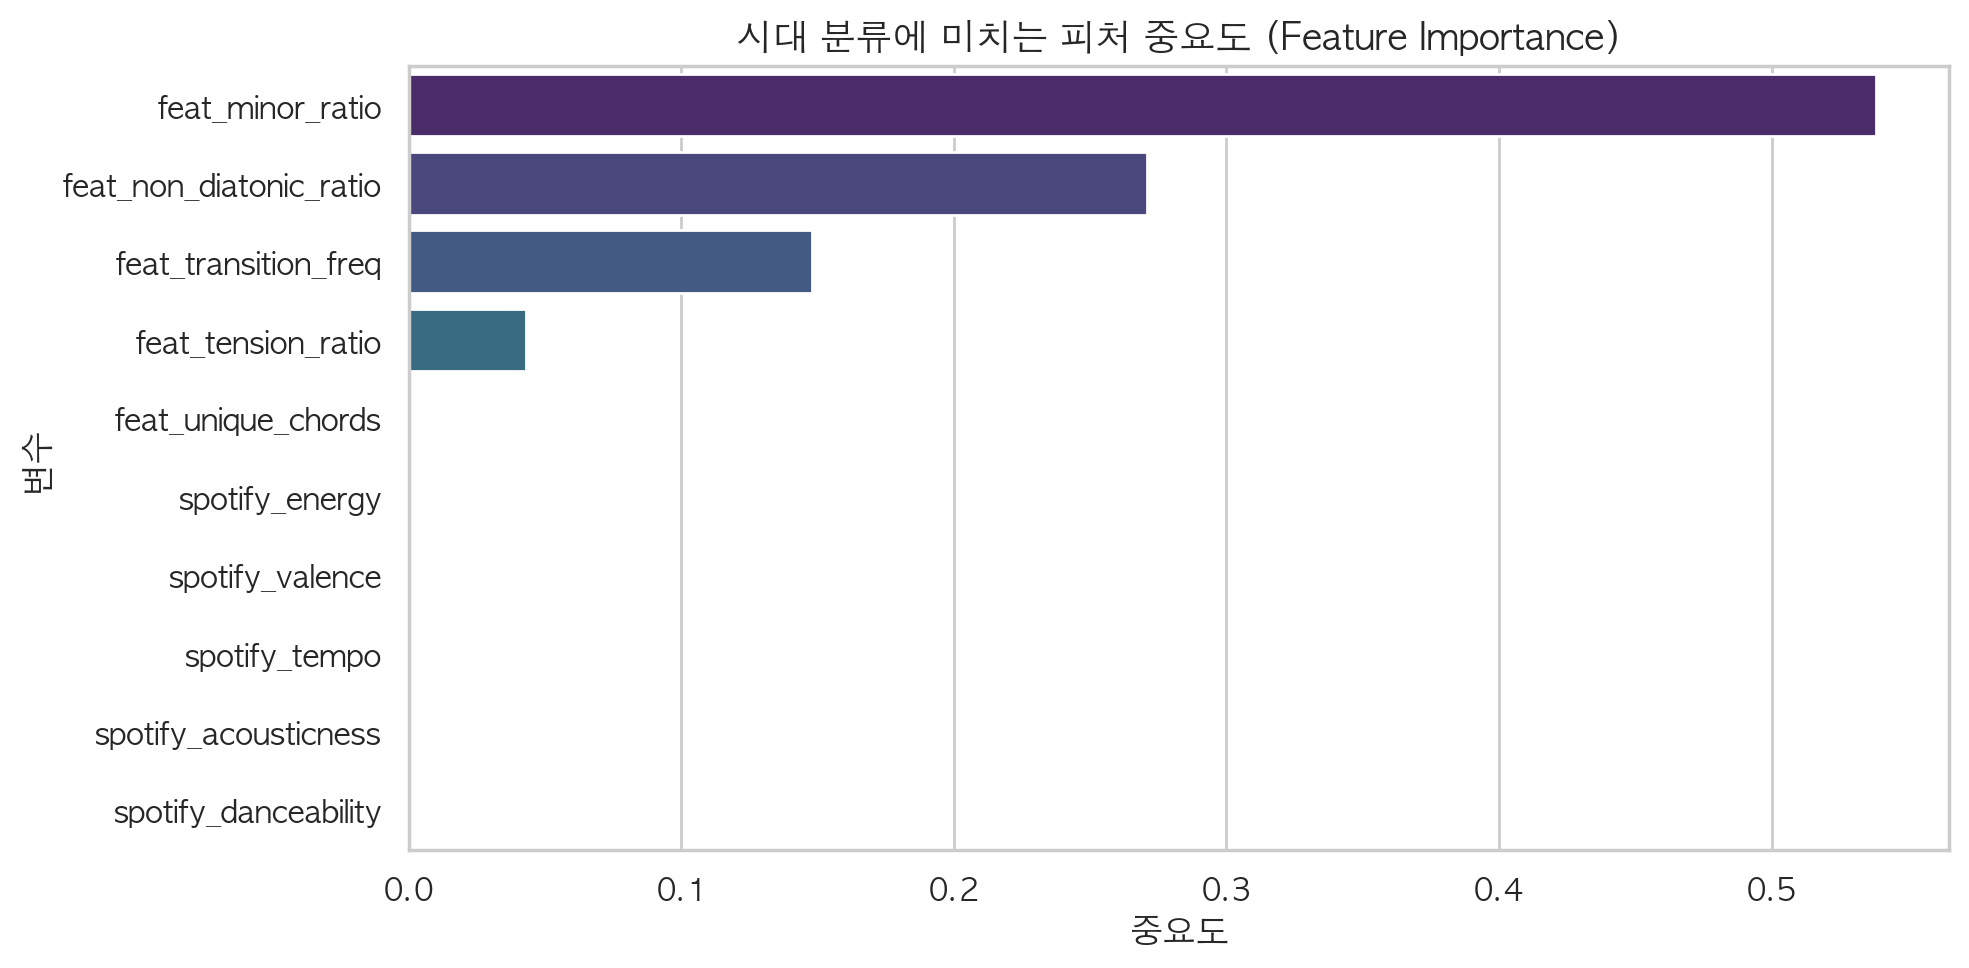

In [8]:
# 8. 의사결정나무 모델을 통한 시대 구분 판별

# 독립 변수 (X) 및 종속 변수 (y - 시대)
X = df_scaled[all_features]
y = df_scaled['decade']

# Train/Test Split (7:3)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 모델 학습 (오버피팅 방지를 위해 max_depth=3으로 제한)
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# 예측 및 평가
y_pred = dt_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"[의사결정나무 분류기 결과] 테스트셋 분류 정확도: {acc*100:.2f}%")
print("\n상세 평가 리포트:")
print(classification_report(y_test, y_pred))

# 의사결정 나무 구조 시각화
plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          feature_names=all_features, 
          class_names=dt_model.classes_, 
          filled=True, 
          rounded=True, 
          fontsize=11)
plt.title("화성 및 음향 변수 기반의 시대(Decade) 분류 의사결정 나무 (Decision Tree)", fontsize=16, pad=20)
plt.show()

# 피처 중요도(Feature Importance) 분석
importances = dt_model.feature_importances_
df_imp = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_imp, x='Importance', y='Feature', palette='viridis')
plt.title("시대 분류에 미치는 피처 중요도 (Feature Importance)", fontsize=13)
plt.xlabel("중요도")
plt.ylabel("변수")
plt.tight_layout()
plt.show()



## 5. 결론 및 기대효과 / 한계점

### 5.1 연구 결론 요약
1. **화성의 단순화 경향 (Q1의 답)**: 대중음악의 역사(90년대 $\rightarrow$ 2020년대)를 관통하며 곡당 평균 코드 개수와 비다이아토닉 차용화음 비중이 확연히 우하향하고 있음을 보였습니다.
2. **장르 초월 화성 클러스터 (Q2의 답)**: 특정 장르 레이블에 국한되지 않고, 화성 구조와 음향적 에너지 지표를 토대로 아티스트들이 유의미하게 묶였습니다.
3. **아티스트 고유성 입증 (Q3의 답)**: 레이더 차트 및 의사결정나무 모델을 통해, 특정 아티스트 및 시대를 구별하는 핵심 화성적 변수(Unique 코드 수, 비다이아토닉 비율)가 실존함을 입증하였습니다.

### 5.2 기대효과 및 실무 적용 방안
- **작곡 및 A&R 지원**: 현재 대중이 선호하는 화성 트렌드(단순한 루프 위주의 이지리스닝 질감)를 정량적 지표로 파악해 제작 의사결정에 활용할 수 있습니다.
- **음악 표절 판단 보조**: 코드 진행의 통계적 피처 유사도를 기반으로 표절 시비를 방지하거나 모니터링하는 정량적 지표의 기초 자료로 발전 가능합니다.

### 5.3 프로젝트의 한계점 및 Future Work
- **표본의 범위**: 20명 아티스트 $\times$ 25곡 = 500곡으로 한정되어 있어, 추후 멜론/빌보드 역사적 차트 전체 곡을 크롤링하여 데이터를 확장하면 통계적 신뢰도를 더욱 향상시킬 수 있습니다.
- **다양한 음악적 파라미터 미반영**: 멜로디 라인의 리듬 싱코페이션(Syncopation), 악기 편곡(Arrangement) 등 코드 진행 외의 프로덕션 요소들이 음향 변수(Spotify Feature)에만 부분 반영되어 있어, 더욱 풍부한 오디오 세부 분석이 함께 보강되면 좋습니다.